[1.  0.5 0.  0.  0. ]
[1.  0.5 0.  0.  0. ]
[0.   0.75 1.   1.   1.  ]
[0.   0.75 1.   1.   1.  ]
[1.   0.25 0.   0.   0.  ]
[1.   0.25 0.   0.   0.  ]
[0.01002513 0.1026334  0.58578644 1.36754447 1.8       ]
[0.01002513 0.1026334  0.58578644 1.36754447 1.8       ]
[1.8        1.36754447 0.58578644 0.1026334  0.01002513]
[1.8        1.36754447 0.58578644 0.1026334  0.01002513]
(np.float64(0.6666666666666667), np.float64(0.22222222222222243), np.float64(0.5656854249492306), np.float64(-0.5999999999999694))
(np.float64(0.6666666666666666), np.float64(0.2222222222222222), np.float64(0.565685424949238), np.float64(-0.6000000000000001))
0.49999999999999983
0.5
25.0
shape > -1 does not hold
-20.0
[ 89.32019966  92.63481456  93.15085401  94.89059019  99.2814983
  88.05388343  88.69261274  94.39784552  85.44956933  91.62802963
  97.7686306   98.85755943 103.82682587  88.75700523  65.72798045
  51.25795099  61.57084388  57.47999876  75.91071074   0.        ]
[141.88467173 143.27111997 147.90145

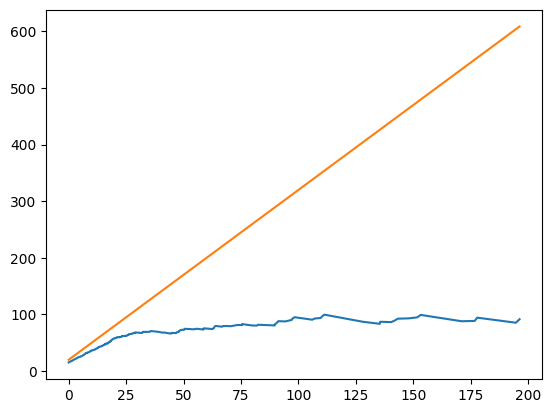

In [1]:
#==============================================================================================
# Packages: Import of required packages for the simulation study
#==============================================================================================
%load_ext autoreload
%autoreload 2

from pathlib import Path
import warnings
from column_row_reduction_study import *
from row_column_reduction_study import *
from column_row_reduction_study_log_reg import *
from row_column_reduction_study_lasso import *
import numpy as np
import matplotlib.pyplot as plt

# eliminate warnings for the linear modeling without column names
warnings.filterwarnings(action='ignore', category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [2]:
#==============================================================================================
# Setting the base path of the data folders
#==============================================================================================
base = Path("/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis")

In [3]:
folder = "Simulation Data/p1000_n1000"
reps = 1
X_list = [
        pd.read_csv(f"{base}/{folder}/X{i + 1}.csv").to_numpy()
        for i in range(reps)
    ]

y_list = [
        pd.read_csv(f"{base}/{folder}/y{i + 1}.csv").to_numpy()
        for i in range(reps)
    ]

[ 3.82098387e-04 -6.38546419e-03 -1.47888129e-03  1.63404172e-04
 -8.21230963e-03 -2.28043667e-03 -1.09293279e-03 -1.34657065e-04
  4.03232842e-03 -2.88047088e-03 -9.05659245e-04 -1.09976307e-03
  2.04903878e-03  1.09494100e-03 -1.29136337e-03  2.60827013e-03
 -9.90359654e-04  3.96984253e-03 -6.06537478e-04  3.29373577e-04
 -7.29434451e-04 -6.03228071e-04 -2.22706586e-04  1.95901112e-04
  3.54410711e-04  2.31857148e-03 -3.36817784e-03 -1.51557613e-03
 -1.84194705e-03  2.02189746e-05  6.27121488e-04  6.47339388e-03
  3.65194482e-04  5.56373876e-03 -1.05423206e-03  7.33103015e-04
  2.92613862e-04 -1.74068577e-03 -1.21329829e-03  3.62383338e-03
 -2.40764442e-04 -1.33066812e-03  1.50609052e-03 -3.19401254e-03
 -1.35229264e-03  1.88808139e-03 -4.75473993e-04  5.76788253e-04
 -1.46322297e-03 -5.51591410e-04  1.77339289e-04  4.14660390e-03
  2.23977835e-03 -4.31467366e-03 -1.64738859e-03 -2.30879623e-03
  3.98738965e-03  1.30939662e-02 -2.48578017e-04 -3.14360142e-03
  8.29257521e-04  2.20938

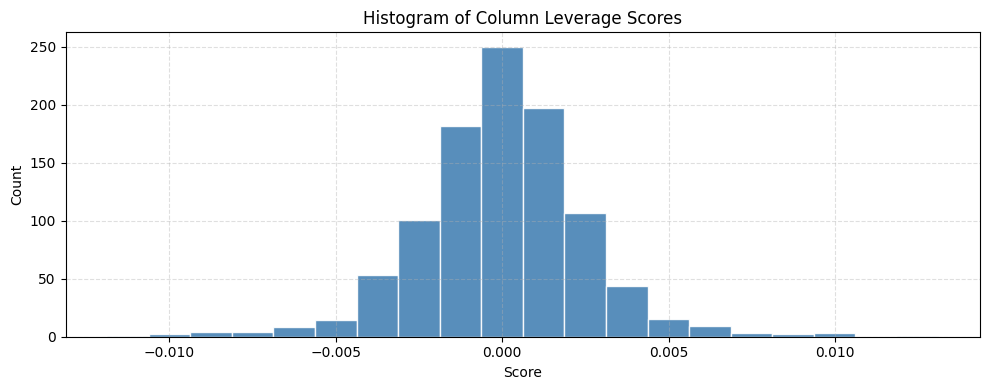

In [15]:
scores = get_cross_leverage_scores_svd(X_list[0], y_list[0], 100, rank_reduce=True)
print(scores)

plt.figure(figsize=(10,4))
plt.hist(scores, bins=20, color="steelblue", edgecolor="white", alpha=0.9)
plt.title("Histogram of Column Leverage Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [11]:
np.allclose(
    get_cross_leverage_scores_svd(X_list[0], y_list[0], 50, rank_reduce=True),
    get_cross_leverage_scores(X_list[0], y_list[0], 50, rank_reduce=True),
    atol=1e-10
)


False